In [1]:
from dateutil.parser import parse 
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
plt.rcParams.update({'figure.figsize': (10, 7), 'figure.dpi': 120})

import dateutil
import calendar

import matplotlib.pyplot as plt

Base de Dados contem as datas e duração das chamadas feitas por um telefone celular
As principais colunas são:

- date: Data e hora da chamada
- duration: 
    - A duração (em segundos) para cada chamada, item=call
    - Total em MB para data, item=data
    - numero de mensagens SMS enviadas, item=sms 
- item: evento de ocorrencia: call, sms, ou data
- month: mês/ano da cobrança
- network: rede móvel utilizada para cada chamada ou envio de SMS
- network_type: mobile, international (‘world’), voicemail, landline, or other (‘special’) number.

Referencia:https://www.shanelynn.ie/summarising-aggregation-and-grouping-data-in-python-pandas/

## 1. Load data Set

In [2]:
# dataset source:
data = pd.read_csv('C://Users/crisr/Documents/ASN_Rocks/Series_Temporais/2. Curso_Completo/Dados/phone_data.csv')
data.head(20)

,index,date,duration,item,month,network,network_type
0,0,15/10/14 06:58,34.429,data,2014-11,data,data
1,1,15/10/14 06:58,13.000,call,2014-11,Vodafone,mobile
2,2,15/10/14 14:46,23.000,call,2014-11,Meteor,mobile
3,3,15/10/14 14:48,4.000,call,2014-11,Tesco,mobile
4,4,15/10/14 17:27,4.000,call,2014-11,Tesco,mobile
5,5,15/10/14 18:55,4.000,call,2014-11,Tesco,mobile
6,6,16/10/14 06:58,34.429,data,2014-11,data,data
7,7,16/10/14 15:01,602.000,call,2014-11,Three,mobile
8,8,16/10/14 15:12,1050.000,call,2014-11,Three,mobile
9,9,16/10/14 15:30,19.000,call,2014-11,voicemail,voicemail


In [3]:
# Convert date from string to date times
data['date'] = data['date'].apply(dateutil.parser.parse, dayfirst=True)
data.head()

,index,date,duration,item,month,network,network_type
0,0,2014-10-15 06:58:00,34.429,data,2014-11,data,data
1,1,2014-10-15 06:58:00,13.000,call,2014-11,Vodafone,mobile
2,2,2014-10-15 14:46:00,23.000,call,2014-11,Meteor,mobile
3,3,2014-10-15 14:48:00,4.000,call,2014-11,Tesco,mobile
4,4,2014-10-15 17:27:00,4.000,call,2014-11,Tesco,mobile


In [4]:
#create var hour, day, month, year, week
data['hour'] = data['date'].dt.strftime('%H')
data['day'] = data['date'].dt.strftime('%d')
data['month_1'] = data['date'].dt.strftime('%m')
data['year'] = data['date'].dt.strftime('%Y')
data['week'] = data['date'].dt.strftime('%W')
data.head()

,index,date,duration,item,month,network,network_type,hour,day,month_1,year,week
0,0,2014-10-15 06:58:00,34.429,data,2014-11,data,data,06,15,10,2014,41
1,1,2014-10-15 06:58:00,13.000,call,2014-11,Vodafone,mobile,06,15,10,2014,41
2,2,2014-10-15 14:46:00,23.000,call,2014-11,Meteor,mobile,14,15,10,2014,41
3,3,2014-10-15 14:48:00,4.000,call,2014-11,Tesco,mobile,14,15,10,2014,41
4,4,2014-10-15 17:27:00,4.000,call,2014-11,Tesco,mobile,17,15,10,2014,41


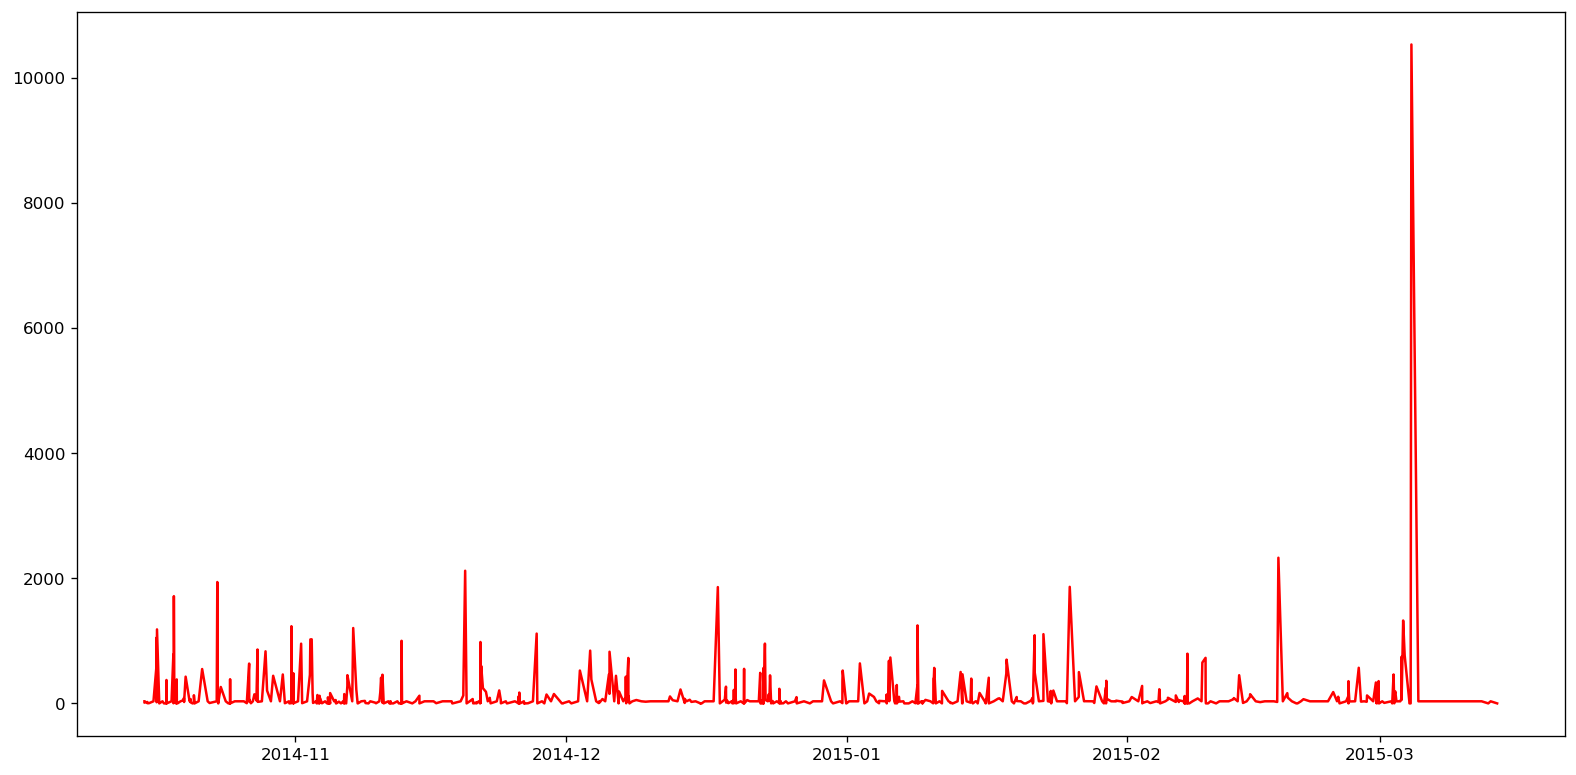

In [5]:
################################################
# Plotando o gráfico da duração por data
plt.figure(figsize=(16,8))
plt.plot(data['date'],data['duration'], color='red')

## 2. Summarising the DataFrame

In [6]:
# How many rows the dataset
data['item'].count()

830

In [7]:
# What was the longest phone call / data entry?
data['duration'].max()

10528.0

In [8]:
# How many seconds of phone calls are recorded in total?
data['duration'][data['item'] == 'call'].sum()

92321.0

In [9]:
# How many entries are there for each month?
data['month'].value_counts()

2014-11    230
2015-01    205
2014-12    157
2015-02    137
2015-03    101
Name: month, dtype: int64

In [10]:
# Number of non-null unique network entries
data['network'].nunique()

9

## 3. Summarising Groups in the DataFrame

## 3.1 DAY - Summarising and plot new variables 

In [11]:
## Sumariza a variavel duration considerando item=call
# Intervalo de Tempo: dia
# Método de acumulação: max, min, total
data_day = data[data['item'] == 'call'].groupby(['year','month_1', 'day']).agg(
    # Get max of the duration column for each group
    max_duration=('duration', max),
    # Get min of the duration column for each group
    min_duration=('duration', min),
    # Get sum of the duration column for each group
    sum_duration=('duration', sum)
    # Get mean of the duration column for each group
    #mean_duration=('duration', )
)

In [12]:
data_day.head()

max_duration  min_duration  sum_duration
year month_1 day                                          
2014 10      15           23.0           4.0          48.0
             16         1183.0          19.0        2854.0
             17          375.0           4.0         471.0
             18         1714.0           3.0        3089.0
             19          428.0          23.0         628.0

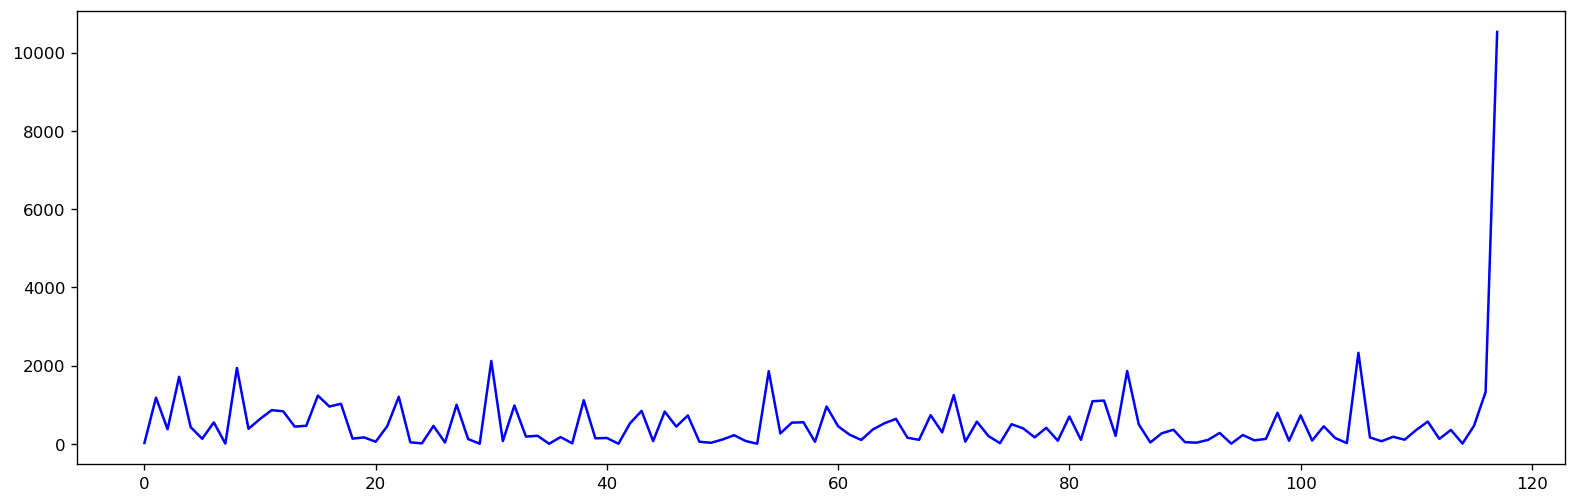

In [13]:
##############################################
################# Day - Max ##################
##############################################
# plt.figure(figsize=(16,5))
# plt.plot(list(data_day['max_duration']), 'o', color='green')
plt.figure(figsize=(16,5))
plt.plot(list(data_day['max_duration']), color='blue')

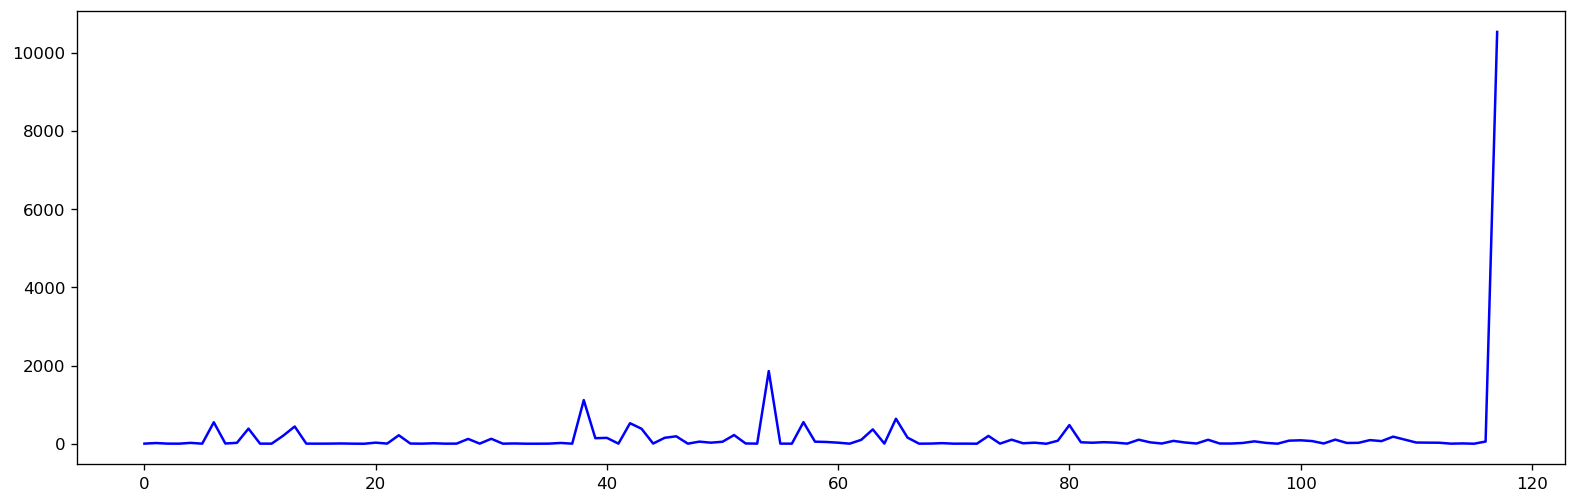

In [14]:
##############################################
################# Day - Min ##################
##############################################
# plt.figure(figsize=(16,5))
# plt.plot(list(data_day['min_duration']), 'o', color='green')
plt.figure(figsize=(16,5))
plt.plot(list(data_day['min_duration']), color='blue')

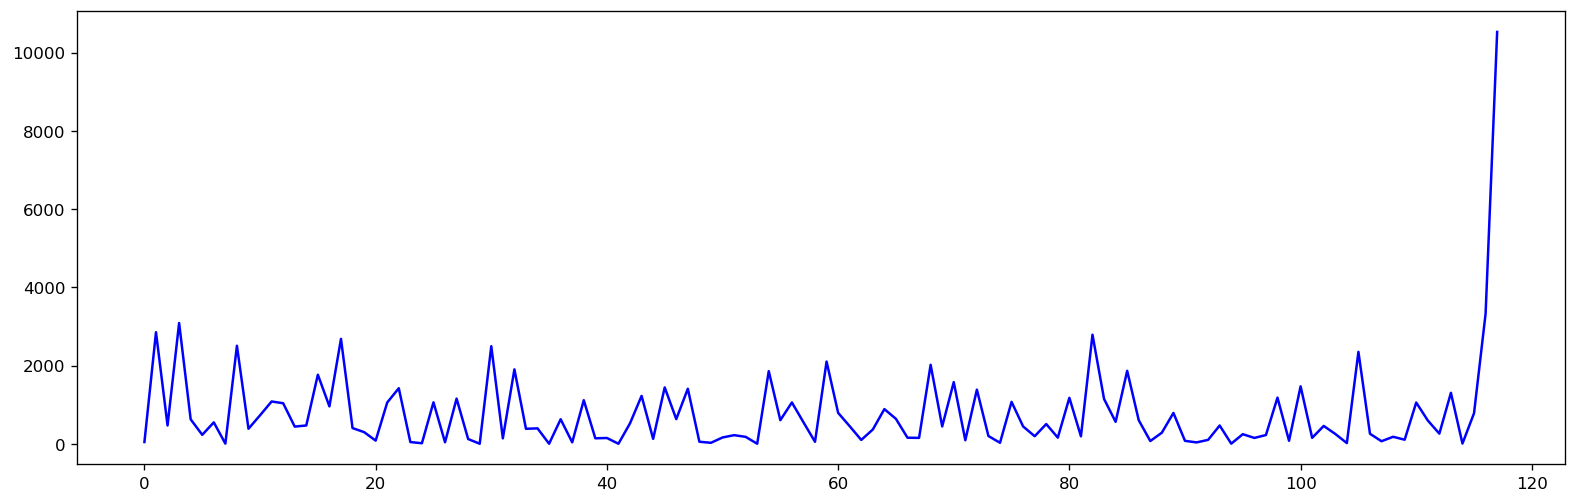

In [15]:
##############################################
################# Day - Sum ##################
##############################################
# plt.figure(figsize=(16,5))
# plt.plot(list(data_day['sum_duration']), 'o', color='green')
plt.figure(figsize=(16,5))
plt.plot(list(data_day['sum_duration']), color='blue')

## 3.2 MONTH - Summarising and plot new variables 

In [16]:
## Sumariza a variavel duration considerando item=call
# Intervalo de Tempo: mês
# Método de acumulação: max, min, total
data_month = data[data['item'] == 'call'].groupby(['year','month_1']).agg(
    # Get max of the duration column for each group
    max_duration=('duration', max),
    # Get min of the duration column for each group
    min_duration=('duration', min),
    # Get sum of the duration column for each group
    sum_duration=('duration', sum)
    # Get mean of the duration column for each group
    #mean_duration=('duration', )
)

In [17]:
data_month.head()

max_duration  min_duration  sum_duration
year month_1                                          
2014 10             1940.0           3.0       16309.0
     11             2120.0           1.0       16780.0
     12             1859.0           3.0       14861.0
2015 01             1863.0           1.0       18705.0
     02             2328.0           2.0       11019.0

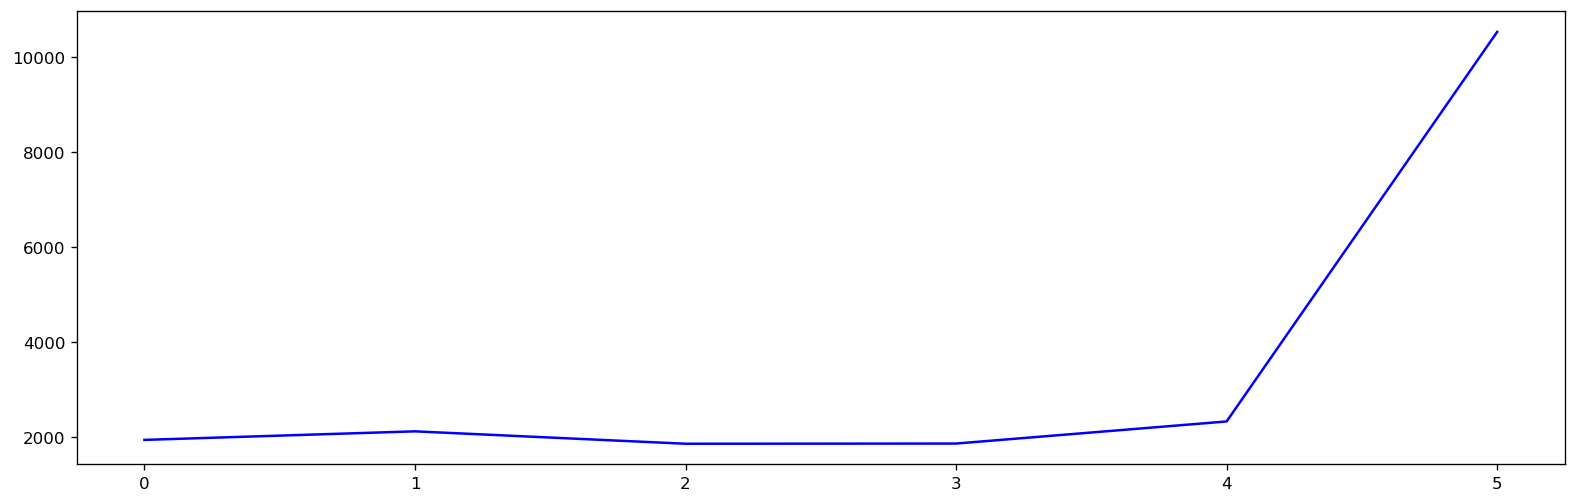

In [18]:
##############################################
############### Month - Max ##################
##############################################
# plt.figure(figsize=(16,5))
# plt.plot(list(data_month['max_duration']), 'o', color='green')
plt.figure(figsize=(16,5))
plt.plot(list(data_month['max_duration']), color='blue')

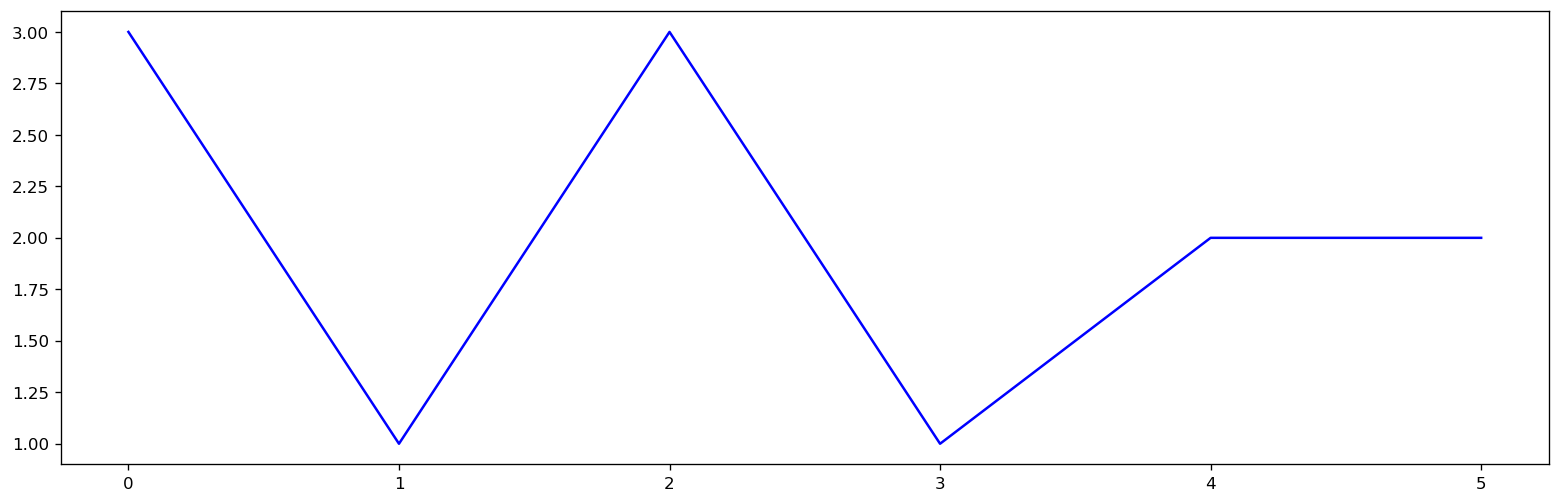

In [19]:
##############################################
############### Month - Min ##################
##############################################
# plt.figure(figsize=(16,5))
# plt.plot(list(data_month['min_duration']), 'o', color='green')
plt.figure(figsize=(16,5))
plt.plot(list(data_month['min_duration']), color='blue')

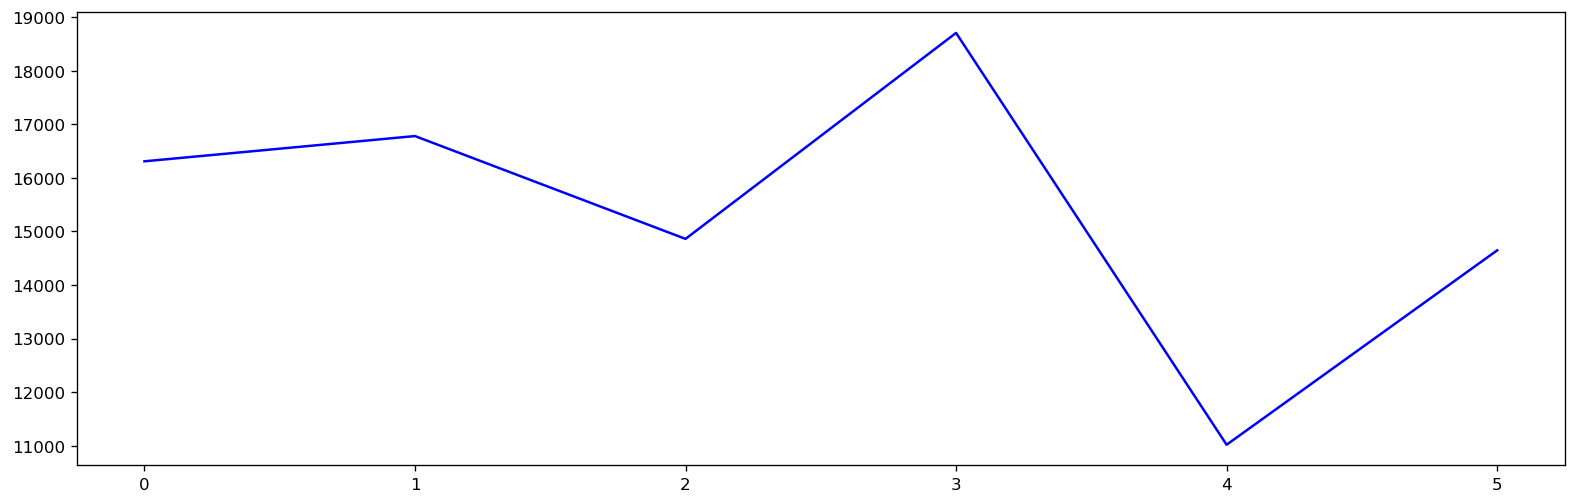

In [20]:
##############################################
############### Month - Sum ##################
##############################################
# plt.figure(figsize=(16,5))
# plt.plot(list(data_month['sum_duration']), 'o', color='green')
plt.figure(figsize=(16,5))
plt.plot(list(data_month['sum_duration']), color='blue')